##  Basic Library imports

In [2]:
import os
import pandas as pd 

from utils import download_images

##  Read Train Dataset

In [4]:
DATASET_FOLDER = '../dataset/train_split'
IMAGE_DIR = '../images/train_part1'
train_set = pd.read_csv(os.path.join(DATASET_FOLDER, 'part1.csv'))
# val_set = pd.read_csv(os.path.join(DATASET_FOLDER, '../dataset/val_split.csv'))

In [5]:
download_images(train_set['image_link'], IMAGE_DIR)

  0%|          | 1/19611 [00:13<73:39:03, 13.52s/it]

Remote end closed connection without response
<urlopen error [Errno 101] Network is unreachable>Warning: Not able to download - https://m.media-amazon.com/images/I/61AfhCxazvL.jpg
<urlopen error [Errno 101] Network is unreachable>

<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
Remote end closed connection without response
Remote end closed connection without response
Remote end closed connection without response
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name resolution>
<urlopen error [Errno -3] Temporary failure in name re

Process ForkPoolWorker-195:
  0%|          | 2/19611 [57:33<9405:52:53, 1726.82s/it]Process ForkPoolWorker-193:
Process ForkPoolWorker-198:
Process ForkPoolWorker-178:
Process ForkPoolWorker-173:
Process ForkPoolWorker-171:
Process ForkPoolWorker-121:
Process ForkPoolWorker-138:



KeyboardInterrupt: 

In [7]:
def check_and_download_missing_images(df, image_dir, download_func= None):
    missing_links = []
    for link in df['image_link']:
        image_name = os.path.basename(link)
        image_path = os.path.join(image_dir, image_name)
        if not os.path.exists(image_path):
            missing_links.append(link)
            print(f"Missing: {image_name}")
    if missing_links != None:
        download_func(missing_links, image_dir)
        pass
    return missing_links

# Example usage:
missing = check_and_download_missing_images(train_set, IMAGE_DIR, download_images)
print(f"Missing images downloaded: {len(missing)}")



Missing: 71IpzCNmNqL.jpg
Missing: 61zwmvBy6ZL.jpg
Missing: 71Z1b09O3gL.jpg
Missing: 61mUx1fFZ6L.jpg
Missing: 71LDTxQO0sL.jpg
Missing: 91rCbrBhkYL.jpg
Missing: 8147sCmq5BL.jpg
Missing: 81t2iDd9l9L.jpg
Missing: 61AfhCxazvL.jpg
Missing: 91gemzAL4HL.jpg
Missing: 21dFOn1fiXL.jpg
Missing: 81xRrXi1XxL.jpg
Missing: 614l41Vd8NL.jpg
Missing: 81xx0wfcZoL.jpg
Missing: 81Em4VZuclL.jpg
Missing: 11bb2NTKocL.jpg
Missing: 81daeBjrheL.jpg
Missing: 71tqS-0-seL.jpg
Missing: 319Bz9JVhmL.jpg
Missing: 81wkxLcdLnL.jpg
Missing: 91VKy4RAdTL.jpg
Missing: 71+eCOgjx0L.jpg
Missing: 91dikSnIdwL.jpg
Missing: 618et2GIHeL.jpg
Missing: 71ElLkoWeHL.jpg
Missing: 91idsXBAKVL.jpg
Missing: 61N3e0pzG7L.jpg
Missing: 61oyELfTRmL.jpg
Missing: 81e1Z8OqdGL.jpg
Missing: 51N4lenZ8YL.jpg
Missing: 61DtzYv6orL.jpg
Missing: 713CTxz20sL.jpg
Missing: 718MBw2OMzL.jpg
Missing: 81MeTm-mSNL.jpg
Missing: 91+hwKPpxXL.jpg
Missing: 81f5LC-3HnL.jpg
Missing: 51KoEbApEJL.jpg
Missing: 71kKMfehUfL.jpg
Missing: 612WfBI7EmL.jpg
Missing: 61mE6FWyQoL.jpg


100%|██████████| 56/56 [00:20<00:00,  2.70it/s]

Missing images downloaded: 56


In [ ]:
assert len(os.listdir('../images/train_part1')) > 0

In [8]:
train_set['basename'] = train_set['image_link'].astype(str).str.strip().apply(os.path.basename)
duplicates = train_set[train_set.duplicated('basename', keep=False)]

to_remove = []
for basename, group in duplicates.groupby('basename'):
    to_remove.extend(group.index.tolist()[1:]) 


train_set_clean = train_set.drop(to_remove).drop(columns=['basename'])
print(f"Rows before: {len(train_set)}, after removing multi-price images: {len(train_set_clean)}")

train_set_clean.to_csv(os.path.join(DATASET_FOLDER, 'part1.csv'), index=False)
del train_set, duplicates, to_remove

Rows before: 19611, after removing multi-price images: 19592


In [9]:
print("Total rows in CSV:", len(train_set_clean))
print("Rows with null image_link:", train_set_clean['image_link'].isnull().sum())
print("Rows with empty image_link:", (train_set_clean['image_link'].astype(str).str.strip() == '').sum())

unique_links = train_set_clean['image_link'].dropna().astype(str).str.strip().unique()
print("Unique image links:", len(unique_links))

basenames = train_set_clean['image_link'].dropna().astype(str).str.strip().apply(os.path.basename)
print("Unique image filenames (basenames):", basenames.nunique())

print("Files in image directory:", len(os.listdir('../images/train_part1')))

# Optionally, print a few duplicate basenames
dup_basenames = basenames[basenames.duplicated(keep=False)]
if not dup_basenames.empty:
    print("Sample duplicate basenames:")
    print(dup_basenames.value_counts().head())
    # For each duplicate basename, check if price is different
    for basename in dup_basenames.unique():
        rows = train_set_clean[train_set_clean['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) == basename]
        unique_prices = rows['price'].unique()
        if len(unique_prices) > 1:
            print(f"Image '{basename}' has multiple prices: {unique_prices}")
        else:
            print(f"Image '{basename}' has a single price: {unique_prices[0]}")
else:
    print("No duplicate basenames found.")

Total rows in CSV: 19592
Rows with null image_link: 0
Rows with empty image_link: 0
Unique image links: 19592
Unique image filenames (basenames): 19592
Files in image directory: 19592
No duplicate basenames found.


####  There are some rows that do not have an image at all.

Let's remove them

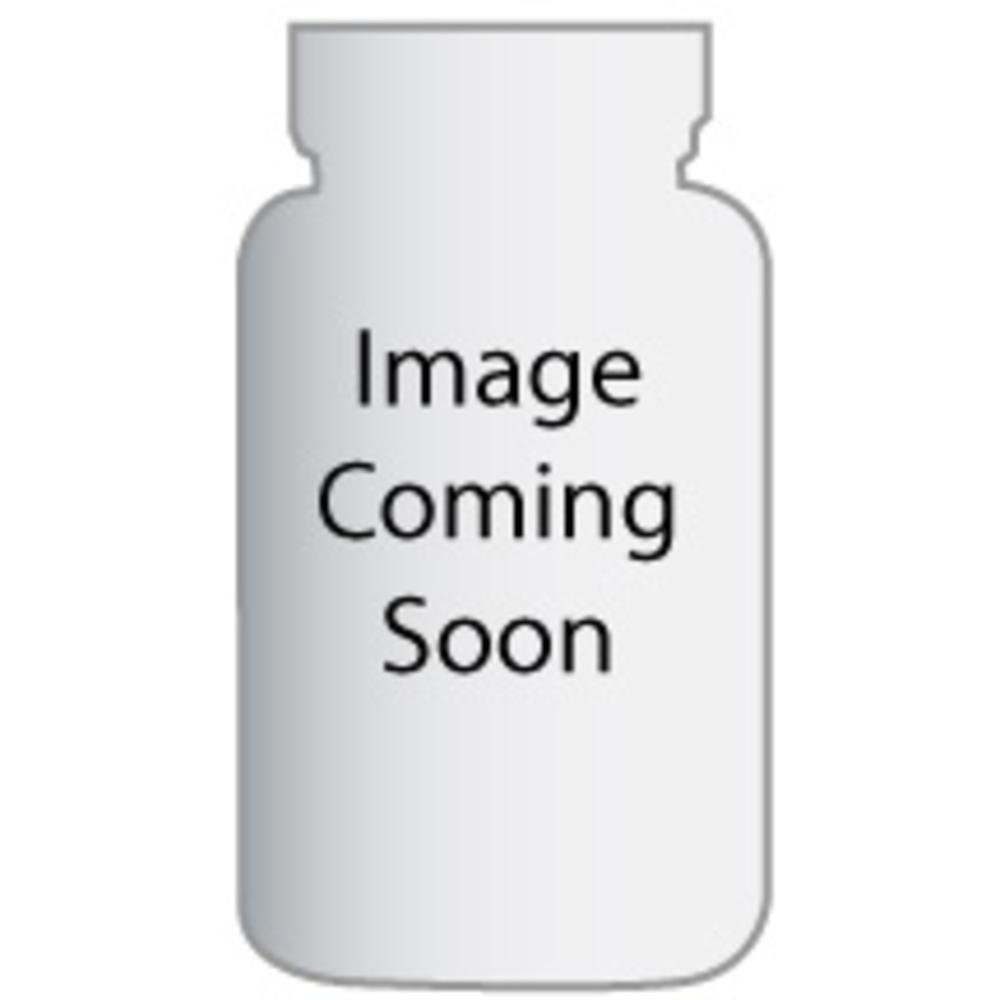

In [16]:
from IPython.display import Image, display

image_path = os.path.join('../images/train_part1', '51m1gdQJW2L.jpg')
display(Image(filename=image_path))

In [17]:
image_to_remove = '51m1gdQJW2L.jpg'
parts = ['part1.csv', 'part2.csv', 'part3.csv']

for part in parts:
    csv_path = os.path.join(DATASET_FOLDER, part)
    df = pd.read_csv(csv_path)
    # Remove rows where the basename of image_link matches the target image
    filtered_df = df[df['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) != image_to_remove]
    filtered_df.to_csv(csv_path, index=False)
    print(f"Removed rows with {image_to_remove} from {part}: {len(df) - len(filtered_df)} rows removed.")

Removed rows with 51m1gdQJW2L.jpg from part1.csv: 16 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part2.csv: 10 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part3.csv: 16 rows removed.


#### Rename to ID

In [10]:
basename_to_id = dict(zip(train_set_clean['image_link'].astype(str).str.strip().apply(os.path.basename), train_set_clean['sample_id'].astype(str)))

renamed = 0
for fname in os.listdir(IMAGE_DIR):
    if fname in basename_to_id:
        new_name = f"{basename_to_id[fname]}.jpg"
        src = os.path.join(IMAGE_DIR, fname)
        dst = os.path.join(IMAGE_DIR, new_name)
        if src != dst:
            os.rename(src, dst)
            print(f"Renamed {fname} -> {new_name}")
            renamed += 1
print(f"Total images renamed: {renamed}")

Renamed 711XDMTBYML.jpg -> 122173.jpg
Renamed 61KhibbQMML.jpg -> 81102.jpg
Renamed 61MAOSPqpbL.jpg -> 170220.jpg
Renamed 71QhXJJRcuL.jpg -> 99242.jpg
Renamed 71gDmYALTES.jpg -> 138627.jpg
Renamed 811332BIPiL.jpg -> 20017.jpg
Renamed 71-N14Ly52L.jpg -> 214823.jpg
Renamed 715K7mnzYkL.jpg -> 210375.jpg
Renamed 31B7oRKO00L.jpg -> 44554.jpg
Renamed 71EyS94cJZL.jpg -> 61644.jpg
Renamed 61O97doFKSL.jpg -> 249125.jpg
Renamed 810VFofgMxL.jpg -> 192424.jpg
Renamed 816NIyilHCL.jpg -> 241437.jpg
Renamed 71KqKrYwJ3L.jpg -> 1480.jpg
Renamed 81+Cv0O7kHL.jpg -> 171363.jpg
Renamed 618VqO9jYQL.jpg -> 117068.jpg
Renamed 715UFfBZsCL.jpg -> 132081.jpg
Renamed 71iK4wQy9mL.jpg -> 25016.jpg
Renamed 81ynTA+t-IL.jpg -> 258920.jpg
Renamed 719F1Kk6LCL.jpg -> 145340.jpg
Renamed 81ryjbxaPaL.jpg -> 58713.jpg
Renamed 91Rr53wyvTL.jpg -> 236657.jpg
Renamed 81UvXEu98vL.jpg -> 24564.jpg
Renamed 81YRjWkFgAL.jpg -> 138591.jpg
Renamed 81Vt-62EJjL.jpg -> 199913.jpg
Renamed 616czjA2SrL.jpg -> 154824.jpg
Renamed 51+6OvU1+qL.jp

In [3]:
import zipfile

images_dir = '../images/train_part1'
zip_path = '../train_part1.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(images_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(images_dir))
            zipf.write(file_path, arcname)

print(f"Images compressed and saved to {zip_path}")

Images compressed and saved to ../train_part1.zip


In [ ]:
# rm -rf ../images

##  Read Val Dataset

In [9]:
DATASET_FOLDER = '../dataset/val_split'
IMAGE_DIR = '../images/val_part1'
train_set = pd.read_csv(os.path.join(DATASET_FOLDER, 'part1.csv'))

In [ ]:
download_images(train_set['image_link'], IMAGE_DIR)

 11%|█         | 553/4997 [00:36<02:44, 27.09it/s] 

<urlopen error [Errno -3] Temporary failure in name resolution>


 24%|██▎       | 1186/4997 [01:49<03:55, 16.20it/s]

<urlopen error [Errno 101] Network is unreachable>


100%|██████████| 4997/4997 [02:49<00:00, 29.51it/s]


In [ ]:
def check_and_download_missing_images(df, image_dir, download_func= None):
    missing_links = []
    for link in df['image_link']:
        image_name = os.path.basename(link)
        image_path = os.path.join(image_dir, image_name)
        if not os.path.exists(image_path):
            missing_links.append(link)
            print(f"Missing: {image_name}")
    if missing_links != None:
        download_func(missing_links, image_dir)
        pass
    return missing_links

# Example usage:
missing = check_and_download_missing_images(train_set, IMAGE_DIR, download_images)
print(f"Missing images downloaded: {len(missing)}")

0it [00:00, ?it/s]

Missing images downloaded: 0


In [ ]:
train_set['basename'] = train_set['image_link'].astype(str).str.strip().apply(os.path.basename)
duplicates = train_set[train_set.duplicated('basename', keep=False)]

to_remove = []
for basename, group in duplicates.groupby('basename'):
    to_remove.extend(group.index.tolist()[1:]) 


train_set_clean = train_set.drop(to_remove).drop(columns=['basename'])
print(f"Rows before: {len(train_set)}, after removing multi-price images: {len(train_set_clean)}")

train_set_clean.to_csv(os.path.join(DATASET_FOLDER, 'part1.csv'), index=False)
del train_set, duplicates, to_remove

Rows before: 4997, after removing multi-price images: 4981


In [18]:
print("Total rows in CSV:", len(train_set_clean))
print("Rows with null image_link:", train_set_clean['image_link'].isnull().sum())
print("Rows with empty image_link:", (train_set_clean['image_link'].astype(str).str.strip() == '').sum())

unique_links = train_set_clean['image_link'].dropna().astype(str).str.strip().unique()
print("Unique image links:", len(unique_links))

basenames = train_set_clean['image_link'].dropna().astype(str).str.strip().apply(os.path.basename)
print("Unique image filenames (basenames):", basenames.nunique())

print("Files in image directory:", len(os.listdir('../images/train_part1')))

# Optionally, print a few duplicate basenames
dup_basenames = basenames[basenames.duplicated(keep=False)]
if not dup_basenames.empty:
    print("Sample duplicate basenames:")
    print(dup_basenames.value_counts().head())
    # For each duplicate basename, check if price is different
    for basename in dup_basenames.unique():
        rows = train_set_clean[train_set_clean['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) == basename]
        unique_prices = rows['price'].unique()
        if len(unique_prices) > 1:
            print(f"Image '{basename}' has multiple prices: {unique_prices}")
        else:
            print(f"Image '{basename}' has a single price: {unique_prices[0]}")
else:
    print("No duplicate basenames found.")

Total rows in CSV: 4981
Rows with null image_link: 0
Rows with empty image_link: 0
Unique image links: 4981
Unique image filenames (basenames): 4981
Files in image directory: 0
No duplicate basenames found.


####  There are some rows that do not have an image at all.

Let's remove them

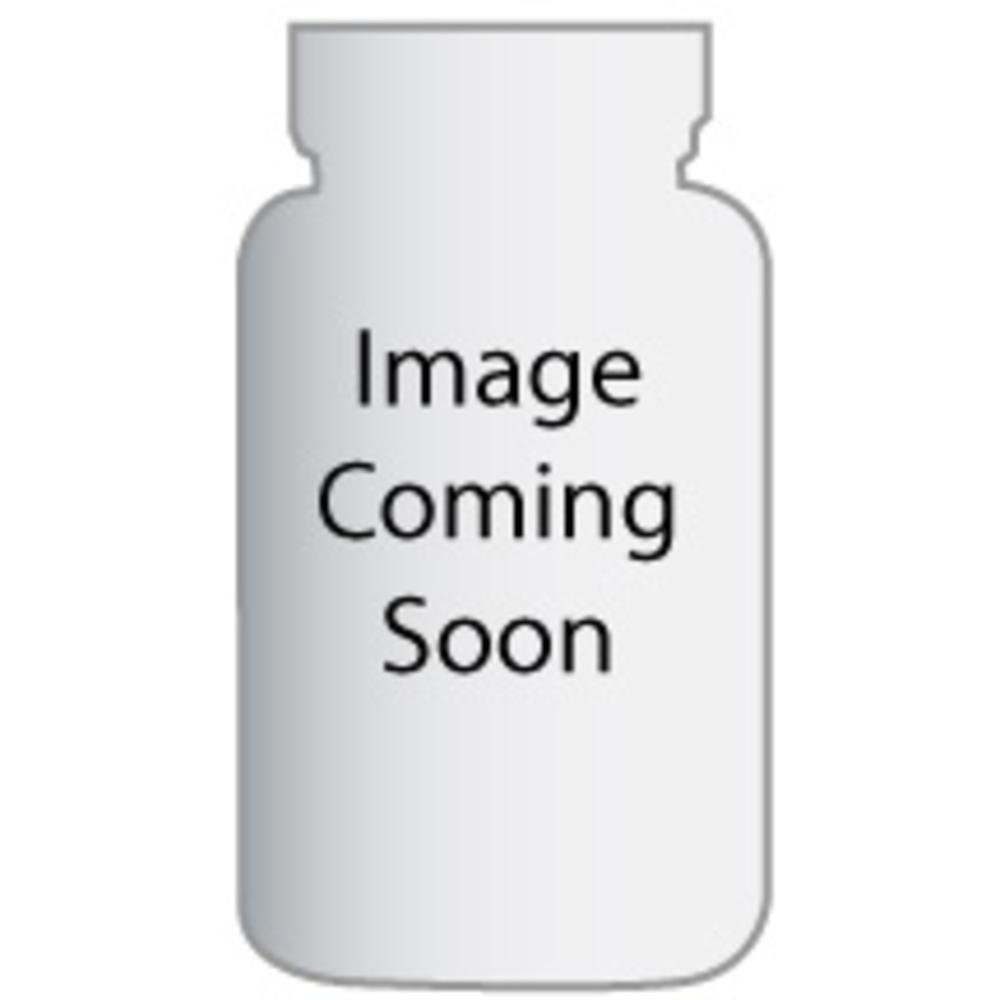

In [5]:
from IPython.display import Image, display

image_path = os.path.join('../images/val_part1', '51m1gdQJW2L.jpg')
display(Image(filename=image_path))

In [6]:
image_to_remove = '51m1gdQJW2L.jpg'
parts = ['part1.csv', 'part2.csv', 'part3.csv']

for part in parts:
    csv_path = os.path.join(DATASET_FOLDER, part)
    df = pd.read_csv(csv_path)
    # Remove rows where the basename of image_link matches the target image
    filtered_df = df[df['image_link'].apply(lambda x: os.path.basename(str(x)).strip()) != image_to_remove]
    filtered_df.to_csv(csv_path, index=False)
    print(f"Removed rows with {image_to_remove} from {part}: {len(df) - len(filtered_df)} rows removed.")

Removed rows with 51m1gdQJW2L.jpg from part1.csv: 3 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part2.csv: 3 rows removed.
Removed rows with 51m1gdQJW2L.jpg from part3.csv: 4 rows removed.


In [ ]:
basename_to_id = dict(zip(train_set_clean['image_link'].astype(str).str.strip().apply(os.path.basename), train_set_clean['sample_id'].astype(str)))

renamed = 0
for fname in os.listdir(IMAGE_DIR):
    if fname in basename_to_id:
        new_name = f"{basename_to_id[fname]}.jpg"
        src = os.path.join(IMAGE_DIR, fname)
        dst = os.path.join(IMAGE_DIR, new_name)
        if src != dst:
            os.rename(src, dst)
            print(f"Renamed {fname} -> {new_name}")
            renamed += 1
print(f"Total images renamed: {renamed}")

Renamed 61XLmEa2ujL.jpg -> 4772.jpg
Renamed 71vbnmJ9bgL.jpg -> 186373.jpg
Renamed 81hzKbfOCxL.jpg -> 98932.jpg
Renamed 81mHUqrowKL.jpg -> 21027.jpg
Renamed 61QA+gxMjeL.jpg -> 180404.jpg
Renamed 81VB2tMgIzL.jpg -> 121606.jpg
Renamed 81XfzrnBLLL.jpg -> 120311.jpg
Renamed 71imnWypfoL.jpg -> 66401.jpg
Renamed 51J1bfzTDgL.jpg -> 83170.jpg
Renamed 71L7QGMaFtL.jpg -> 197157.jpg
Renamed 71B8mJPzv6L.jpg -> 154702.jpg
Renamed 71NEnsIqvtL.jpg -> 131328.jpg
Renamed 71dTPh4N5cL.jpg -> 54928.jpg
Renamed 81stowrjGlL.jpg -> 110672.jpg
Renamed 61Cd5TcJTRL.jpg -> 213636.jpg
Renamed 81hqnMVaf+L.jpg -> 281562.jpg
Renamed 516xm-ra+AL.jpg -> 176288.jpg
Renamed 71JcXoP8ooL.jpg -> 14395.jpg
Renamed 81yKyqCA+xL.jpg -> 148279.jpg
Renamed 81FF9g+wmYL.jpg -> 19368.jpg
Renamed A1ZzRzAyhML.jpg -> 56198.jpg
Renamed 81pJIDXNNtL.jpg -> 96662.jpg
Renamed 51-6PCNu+cL.jpg -> 49826.jpg
Renamed 61aiLkUOx0L.jpg -> 124033.jpg
Renamed 71KyE82ByML.jpg -> 277820.jpg
Renamed 51R3IdmIX4L.jpg -> 299072.jpg
Renamed 61tjBpU1u3L.jpg 

#### Save the folder as a ZIP File

In [20]:
import zipfile

images_dir = '../images/val_part1'
zip_path = '../val_part1.zip'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(images_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, os.path.dirname(images_dir))
            zipf.write(file_path, arcname)

print(f"Images compressed and saved to {zip_path}")

Images compressed and saved to ../val_part1.zip
